# Chapter 2 Lab: Transformer Mechanics from First Principles

**Runtime:** 2–3 minutes · **Difficulty:** intermediate · **Credentials:** none

This lab makes the Transformer's mathematics visible with NumPy. It preserves financial
tokens, creates positional encodings, computes scaled dot-product attention, applies a
causal mask, and visualizes what each query attends to.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/02_transformer_mechanics.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/02_transformer_mechanics.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- implement stable softmax and scaled attention;
- see why the `sqrt(d_k)` scale matters;
- distinguish bidirectional from causal attention;
- construct multi-head projections without projecting twice; and
- connect sequence length to compute and memory.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import seed_everything
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.text import (
    multi_head_attention,
    scaled_dot_product_attention,
    stable_softmax,
    tokenize_financial,
)

set_finance_theme()
rng = seed_everything(202)
sentence = "Revenue grew 12.4% while operating margin fell 80 bps."
tokens = tokenize_financial(sentence)
tokens


['revenue', 'grew', '12.4%', 'while', 'operating', 'margin', 'fell', '80', 'bps', '.']

## 1. Token features and positional encodings

Real models learn dense embeddings. For inspection, we use interpretable token features
and sinusoidal position vectors. This lets us see whether attention is reacting to numbers,
growth language, margin language, or position.


In [3]:
vocabulary_cues = {"revenue": 0, "grew": 1, "margin": 2, "fell": 3}
d_model = 8
features = np.zeros((len(tokens), d_model))
for i, token in enumerate(tokens):
    if token in vocabulary_cues:
        features[i, vocabulary_cues[token]] = 1.0
    features[i, 4] = any(c.isdigit() for c in token)
    features[i, 5] = token.endswith("%")
    features[i, 6] = token in {"bps", "basis"}
    features[i, 7] = 1.0

positions = np.arange(len(tokens))[:, None]
dimensions = np.arange(d_model)[None, :]
angles = positions / np.power(10_000, (2 * (dimensions // 2)) / d_model)
positional = np.where(dimensions % 2 == 0, np.sin(angles), np.cos(angles))
X = features + 0.25 * positional
pd.DataFrame(X, index=tokens, columns=[f"d{i}" for i in range(d_model)]).round(3)


,d0,d1,d2,d3,d4,d5,d6,d7
revenue,1.000,0.250,0.000,0.250,0.000,0.250,0.000,1.25
grew,0.210,1.135,0.025,0.249,0.002,0.250,0.000,1.25
12.4%,0.227,-0.104,0.050,0.245,1.005,1.250,0.000,1.25
while,0.035,-0.247,0.074,0.239,0.007,0.250,0.001,1.25
operating,-0.189,-0.163,0.097,0.230,0.010,0.250,0.001,1.25
margin,-0.240,0.071,1.120,0.219,0.012,0.250,0.001,1.25
fell,-0.070,0.240,0.141,1.206,0.015,0.250,0.001,1.25
80,0.164,0.188,0.161,0.191,1.017,0.249,0.002,1.25
bps,0.247,-0.036,0.179,0.174,0.020,0.249,1.002,1.25
.,0.103,-0.228,0.196,0.155,0.022,0.249,0.002,1.25


## 2. Scaled dot-product attention

The projection matrices below are fixed by the seed. Queries, keys, and values all come
directly from `X`, matching the book's notation.


In [4]:
d_k = 6
W_q = rng.normal(0, 0.45, (d_model, d_k))
W_k = rng.normal(0, 0.45, (d_model, d_k))
W_v = rng.normal(0, 0.45, (d_model, d_k))
Q, K, V = X @ W_q, X @ W_k, X @ W_v
context, weights = scaled_dot_product_attention(Q, K, V)
assert np.allclose(weights.sum(axis=1), 1.0)
print("Context shape:", context.shape)
print("Maximum row-sum error:", np.abs(weights.sum(axis=1) - 1).max())


Context shape: (10, 6)
Maximum row-sum error: 2.220446049250313e-16


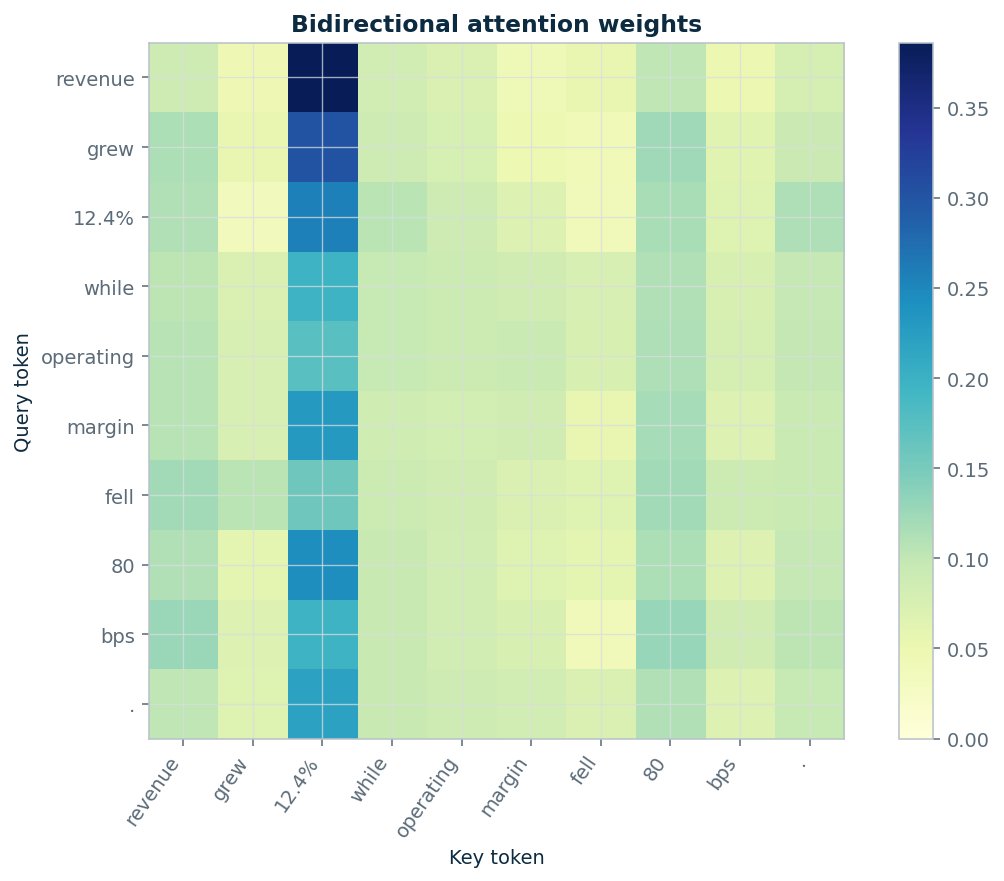

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 6.4))
image = ax.imshow(weights, cmap="YlGnBu", vmin=0, vmax=weights.max())
ax.set_xticks(range(len(tokens)), tokens, rotation=55, ha="right")
ax.set_yticks(range(len(tokens)), tokens)
ax.set(title="Bidirectional attention weights", xlabel="Key token", ylabel="Query token")
fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()


## 3. Causal masking

A decoder must not attend to future tokens during next-token training. The triangular
mask makes future attention numerically impossible rather than merely discouraged.


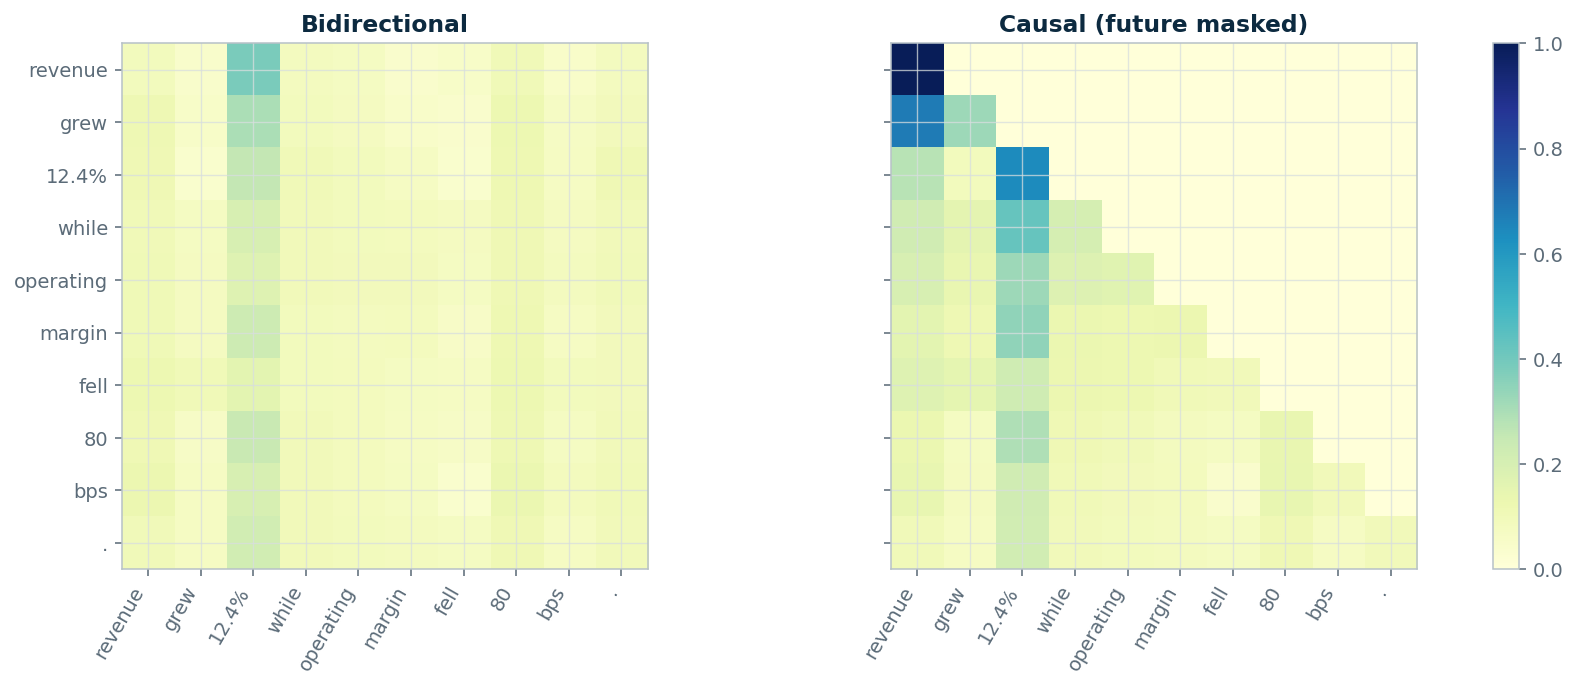

In [6]:
causal_mask = np.tril(np.ones((len(tokens), len(tokens)), dtype=bool))
causal_context, causal_weights = scaled_dot_product_attention(Q, K, V, causal_mask)
assert np.allclose(causal_weights[np.triu_indices(len(tokens), k=1)], 0.0)
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.8), sharex=True, sharey=True, constrained_layout=True
)
for ax, matrix, title in zip(
    axes, [weights, causal_weights], ["Bidirectional", "Causal (future masked)"]
):
    im = ax.imshow(matrix, cmap="YlGnBu", vmin=0, vmax=max(weights.max(), causal_weights.max()))
    ax.set_xticks(range(len(tokens)), tokens, rotation=60, ha="right")
    ax.set_yticks(range(len(tokens)), tokens)
    ax.set_title(title)
fig.colorbar(im, ax=axes, fraction=0.025)


## 4. Why scaling and stable softmax matter

Unscaled dot products become more extreme as `d_k` grows. Naive exponentiation also
overflows on large logits. Both problems are easy to reproduce.


In [7]:
dimensions_to_test = [4, 16, 64, 256, 1024]
rows = []
for dim in dimensions_to_test:
    q = rng.normal(size=(300, dim))
    k = rng.normal(size=(300, dim))
    raw = np.sum(q * k, axis=1)
    rows.append(
        {
            "d_k": dim,
            "raw_std": raw.std(),
            "scaled_std": (raw / np.sqrt(dim)).std(),
        }
    )
scale_demo = pd.DataFrame(rows)
large_logits = np.array([1000.0, 1001.0, 1002.0])
print("Stable softmax:", stable_softmax(large_logits))
scale_demo


Stable softmax: [0.09003057 0.24472847 0.66524096]


,d_k,raw_std,scaled_std
0,4,1.884992,0.942496
1,16,4.230203,1.057551
2,64,7.858140,0.982268
3,256,14.927448,0.932966
4,1024,31.575147,0.986723


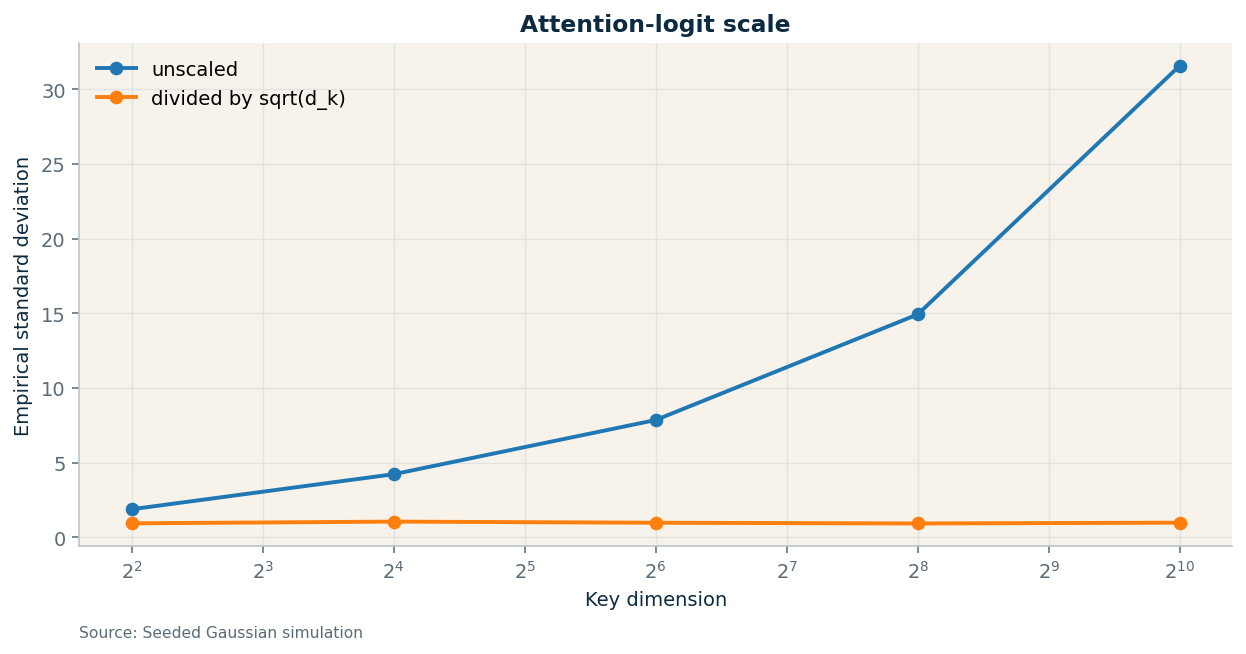

In [8]:
fig, ax = plt.subplots()
ax.plot(scale_demo["d_k"], scale_demo["raw_std"], marker="o", label="unscaled")
ax.plot(scale_demo["d_k"], scale_demo["scaled_std"], marker="o", label="divided by sqrt(d_k)")
ax.set_xscale("log", base=2)
ax.set(title="Attention-logit scale", xlabel="Key dimension", ylabel="Empirical standard deviation")
ax.legend()
finish(ax, "Seeded Gaussian simulation")
plt.tight_layout()


## 5. Multi-head attention

Each head receives `X` and learns a different set of projections. The head contexts are
concatenated and passed through `W_O`; without those two steps this would be three
independent attention calculations, not a complete multi-head layer.


In [9]:
projections = []
for head in range(3):
    wq = rng.normal(0, 0.5, (d_model, 4))
    wk = rng.normal(0, 0.5, (d_model, 4))
    wv = rng.normal(0, 0.5, (d_model, 4))
    projections.append((wq, wk, wv))
W_o = rng.normal(0, 0.4, (3 * 4, d_model))
multi_context, all_head_weights = multi_head_attention(X, projections, W_o)

heads = []
for head, head_weights in enumerate(all_head_weights):
    query_index = tokens.index("margin")
    key_index = int(np.argmax(head_weights[query_index]))
    heads.append(
        {
            "head": head + 1,
            "top_key_for_margin": tokens[key_index],
            "attention_weight": head_weights[query_index, key_index],
            "output_norm": np.linalg.norm(multi_context[query_index]),
        }
    )
print("Concatenated-and-projected output shape:", multi_context.shape)
pd.DataFrame(heads).round(4)


Concatenated-and-projected output shape: (10, 8)


,head,top_key_for_margin,attention_weight,output_norm
0,1,margin,0.1322,1.2893
1,2,fell,0.1653,1.2893
2,3,grew,0.2683,1.2893


## 6. The quadratic cost

Dense attention stores a sequence-by-sequence score matrix per head. The calculation
below shows why chunking, sparse attention, and retrieval become important for long
financial documents.


In [10]:
lengths = np.array([512, 2_048, 8_192, 32_768])
heads_count = 16
bytes_per_value = 2
cost = pd.DataFrame(
    {
        "tokens": lengths,
        "attention_pairs_mn": heads_count * lengths**2 / 1e6,
        "attention_memory_gib": heads_count * lengths**2 * bytes_per_value / 1024**3,
    }
)
cost.round(2)


,tokens,attention_pairs_mn,attention_memory_gib
0,512,4.19,0.01
1,2048,67.11,0.12
2,8192,1073.74,2.00
3,32768,17179.87,32.00


## Takeaways

- Scaled attention is a probability-weighted aggregation, not a magical explanation.
- Causal masks enforce an information boundary inside the architecture.
- Multi-head attention concatenates separate head contexts and applies `W_O`.
- Long financial documents make the quadratic attention matrix operationally expensive.

**Challenge:** replace the fixed projections with a tiny learned next-token model and
compare its train/test loss with the Chapter 1 bigram baseline.
